In [14]:
import functions as fn
import numpy as np
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
from pyEquilibrium.equilibrium import equilibrium as equil
# import pyuda
# client = pyuda.Client()
from scipy.optimize import curve_fit

%matplotlib widget

Thomson time is 0.4001031s


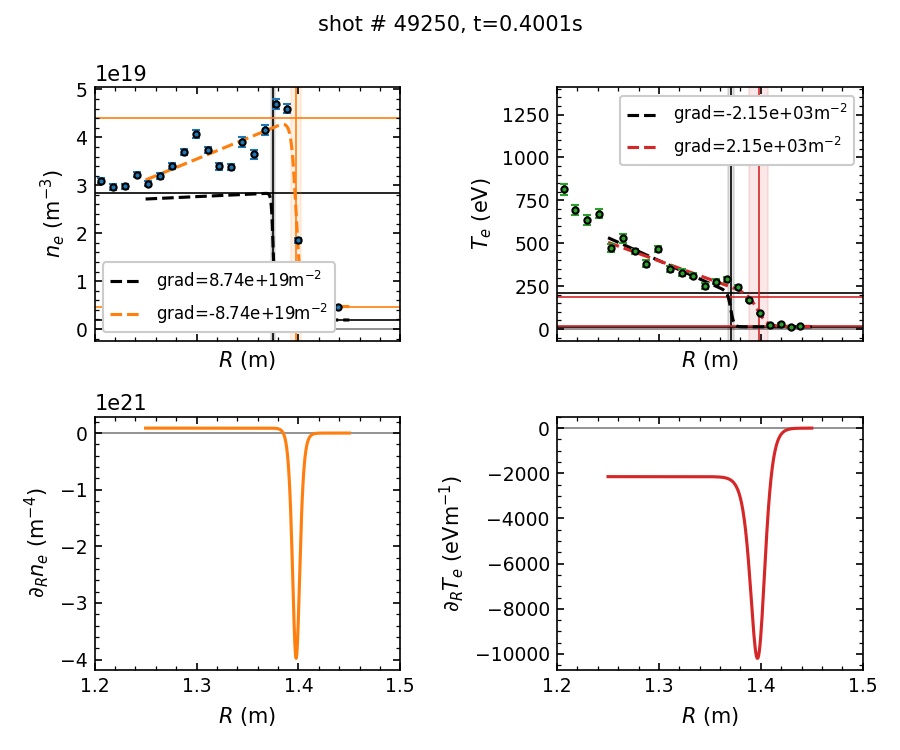

In [15]:
shotn = 49250
twant = 0.4
Rwant = 1.25
Rend = 1.45

time, ne, neErr, Rthomson = HSV.getThomson(shotn, 'n_e')
_, Te, TeErr, _ = HSV.getThomson(shotn, 'T_e')
_, R0ne, heightne, widthne, gradne, bkgdne = HSV.getPedestal(shotn, 'n_e')
_, R0Te, heightTe, widthTe, gradTe, bkgdTe = HSV.getPedestal(shotn, 'T_e')

t = fn.findNearest(time, twant)
print(f'Thomson time is {time[t]:.7f}s')
r = fn.findNearest(Rthomson[t], Rwant)
R = np.linspace(Rwant, Rend, 300)

profilene = HSV.mtanh(R, R0ne[t], heightne[t], widthne[t], gradne[t], bkgdne[t])
profileTe = HSV.mtanh(R, R0Te[t], heightTe[t], widthTe[t], gradTe[t], bkgdTe[t])

boone = np.isfinite(ne[t,r:])
xne = Rthomson[t,r:][boone]
yne = ne[t,r:][boone]
yErrne = neErr[t,r:][boone]
poptne, pcovne = curve_fit(
    HSV.mtanh, xne, yne, sigma=yErrne, absolute_sigma=True, 
    p0=(R0ne[t],heightne[t],widthne[t],gradne[t],bkgdne[t])
)
profile2ne = HSV.mtanh(R, *poptne)

booTe = np.isfinite(Te[t,r:])
xTe = Rthomson[t,r:][booTe]
yTe = Te[t,r:][booTe]
yErrTe = TeErr[t,r:][booTe]
poptTe, pcovTe = curve_fit(
    HSV.mtanh, xTe, yTe, sigma=yErrTe, absolute_sigma=True, 
    p0=(R0Te[t],heightTe[t],widthTe[t],gradTe[t],bkgdTe[t])
)
profile2Te = HSV.mtanh(R, *poptTe)

gradne = HSV.mtanhGradient(R, *poptne)
gradTe = HSV.mtanhGradient(R, *poptTe)


xlim = (1.2, 1.5)

fig, ax = plt.subplots(2, 2, figsize=(6,5), dpi=150, sharex=True)
ax[0,0].errorbar(Rthomson[t], ne[t], yerr=neErr[t], fmt='.', c='C0', mec='k', capsize=2, zorder=3)
ax[0,0].plot(R, profilene, '--k', zorder=2, label=f'grad={gradne[t]:.3g}m$^{{-2}}$')
ax[0,0].plot(R, profile2ne, '--', c='C1', zorder=2, label=f'grad={poptne[-2]:.3g}m$^{{-2}}$')
ax[0,0].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[0,0].legend(fancybox=1, framealpha=1, fontsize=8)

ax[0,0].set_xlabel('$R$ (m)')
ax[0,0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,0].minorticks_on()


ylimne = ax[0,0].get_ylim()
ax[0,0].set_xlim(xlim)
ax[0,0].set_ylim(ylimne)

ax[0,0].plot([R0ne[t], R0ne[t]], ylimne, '-k', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [heightne[t], heightne[t]], '-k', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [bkgdne[t], bkgdne[t]], '-k', lw=0.8, zorder=1)
ax[0,0].fill_between(
    [R0ne[t]-widthne[t]/2.,R0ne[t]+widthne[t]/2.,], 
    [ylimne[0],ylimne[0]], [ylimne[1],ylimne[1]], color='k', alpha=0.1
)

ax[0,0].plot([poptne[0], poptne[0]], ylimne, '-', c='C1', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [poptne[1], poptne[1]], '-', c='C1', lw=0.8, zorder=1)
ax[0,0].plot(xlim, [poptne[-1], poptne[-1]], '-', c='C1', lw=0.8, zorder=1)
ax[0,0].fill_between(
    [poptne[0]-poptne[2]/2.,poptne[0]+poptne[2]/2.,], 
    [ylimne[0],ylimne[0]], [ylimne[1],ylimne[1]], color='C1', alpha=0.1
)

ax[0,1].errorbar(Rthomson[t], Te[t], yerr=TeErr[t], fmt='.', c='C2', mec='k', capsize=2, zorder=3)
ax[0,1].plot(R, profileTe, '--k', zorder=2, label=f'grad={gradTe[t]:.3g}m$^{{-2}}$')
ax[0,1].plot(R, profile2Te, '--', c='C3', zorder=2, label=f'grad={poptTe[-2]:.3g}m$^{{-2}}$')
ax[0,1].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[0,1].legend(fancybox=1, framealpha=1, fontsize=8)

ax[0,1].set_xlabel('$R$ (m)')
ax[0,1].set_ylabel('$T_e$ (eV)')
ax[0,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,1].minorticks_on()


ylimTe = ax[0,1].get_ylim()
ax[0,1].set_xlim(xlim)
ax[0,1].set_ylim(ylimTe)

ax[0,1].plot([R0Te[t], R0Te[t]], ylimTe, '-k', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [heightTe[t], heightTe[t]], '-k', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [bkgdTe[t], bkgdTe[t]], '-k', lw=0.8, zorder=1)
ax[0,1].fill_between(
    [R0Te[t]-widthTe[t]/2.,R0Te[t]+widthTe[t]/2.,], 
    [ylimTe[0],ylimTe[0]], [ylimTe[1],ylimTe[1]], color='k', alpha=0.1
)

ax[0,1].plot([poptTe[0], poptTe[0]], ylimTe, '-', c='C3', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [poptTe[1], poptTe[1]], '-', c='C3', lw=0.8, zorder=1)
ax[0,1].plot(xlim, [poptTe[-1], poptTe[-1]], '-', c='C3', lw=0.8, zorder=1)
ax[0,1].fill_between(
    [poptTe[0]-poptTe[2]/2.,poptTe[0]+poptTe[2]/2.,], 
    [ylimTe[0],ylimTe[0]], [ylimTe[1],ylimTe[1]], color='C3', alpha=0.1
)

ax[1,0].plot(R, gradne, '-', c='C1', zorder=2, )
ax[1,0].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[1,0].set_xlabel('$R$ (m)')
ax[1,0].set_ylabel('$\\partial_R n_e$ (m$^{-4}$)')
ax[1,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,0].minorticks_on()
ax[1,0].set_xlim(xlim)

ax[1,1].plot(R, gradTe, '-', c='C3', zorder=2, )
ax[1,1].plot(xlim, [0.,0], '-', c='gray', lw=0.8, zorder=0)
ax[1,1].set_xlabel('$R$ (m)')
ax[1,1].set_ylabel('$\\partial_R T_e$ (eVm$^{-1}$)')
ax[1,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,1].minorticks_on()
ax[1,1].set_xlim(xlim)

fig.suptitle(f'shot # {shotn}, t={time[t]:.4f}s', fontsize=10)

plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_01.png')

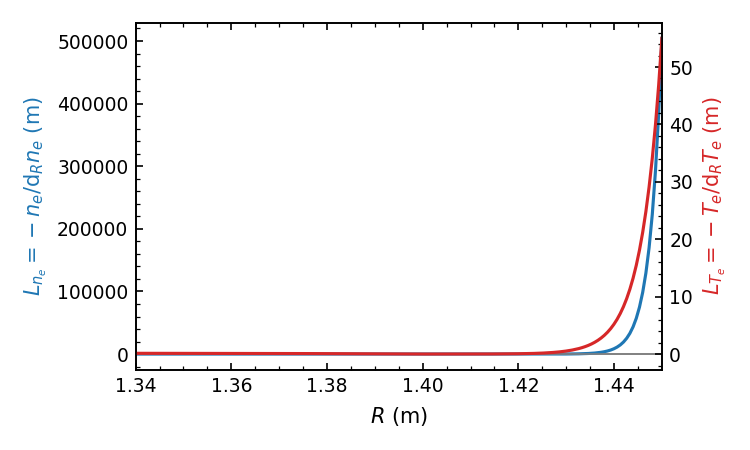

In [3]:
Lne = -profile2ne / gradne
LTe = -profile2Te / gradTe

xlim2 = (1.34, 1.45)

fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=150)
ax.plot(R, Lne, '-', c='C0')
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$L_{n_e} = -n_e / \\mathrm{d}_R n_e$ (m)', c='C0')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim2)
ax2 = ax.twinx()
ax2.plot(R, LTe, '-', c='C3')
ax2.set_ylabel('$L_{T_e} = -T_e / \\mathrm{d}_R T_e$ (m)', c='C3')
ax2.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=True, top=False
)
ax2.minorticks_on()
ax.plot(xlim2, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax2.plot(xlim2, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_02.png')

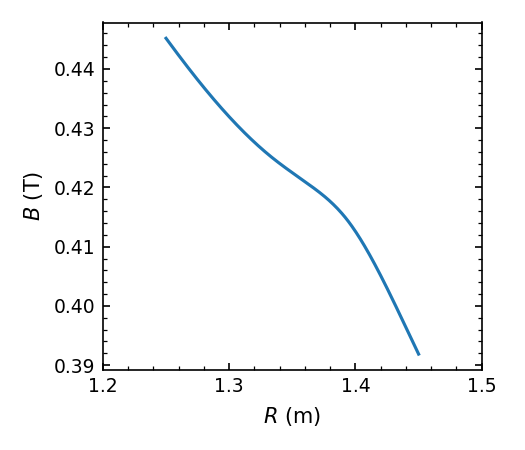

In [4]:
eq = equil(device='MASTU', shot=shotn, time=twant, mastu_prefix='epq')
B = eq.B(R, 0.)[0]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, B)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$B$ (T)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_03.png')

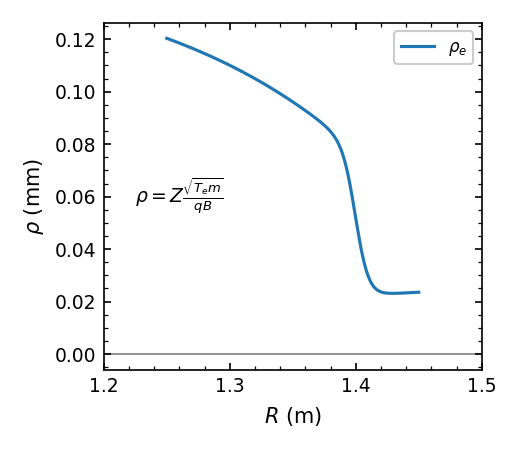

In [5]:
gyro_e = mf.gyroradius(profile2Te, B, Z=1, m=1., q=1., units='eV', particle='electron')
# gyro_i = mf.gyroradius(profile2Te, B, Z=1, m=2., q=1., units='eV', particle='ion')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, gyro_e*1e3, label='$\\rho_e$')
# ax.plot(R, gyro_i*1e3, label='$\\rho_i$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\rho$ (mm)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xlim(xlim)
ax.minorticks_on()
ax.text(
    xlim[0]+0.025, np.mean(ax.get_ylim()), 
    '$\\rho=Z\\frac{\\sqrt{T_e m}}{qB}$',
    ha='left', va='center', fontsize=9
)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_04.png')

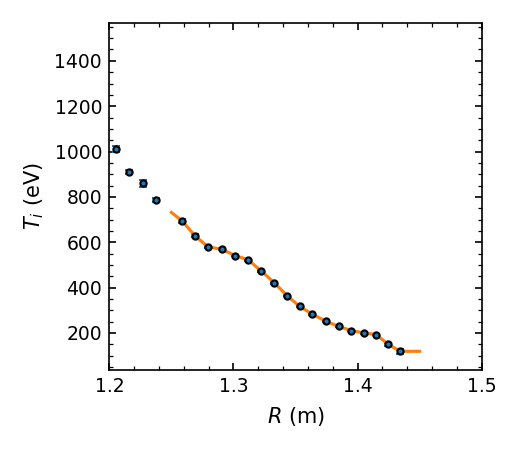

In [6]:
timeCX, RCX, dataCX, errCX = mf.getCXTi(shotn, prnt=False)

tindCX = fn.findNearest(timeCX, twant)
timeCX = timeCX[tindCX]
dataCX = dataCX[tindCX]
errCX = errCX[tindCX]

booCX = np.isfinite(dataCX)
dataCXinterp = np.interp(R, RCX[booCX], dataCX[booCX], )

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.errorbar(RCX, dataCX, yerr=errCX, fmt='.', c='C0', capsize=2, mec='k')
ax.plot(R, dataCXinterp, '-', c='C1')
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$T_i$ (eV)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)

plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_05.png')

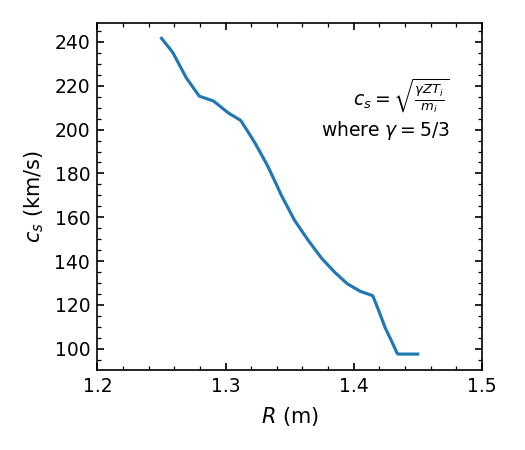

In [7]:
cs = mf.sound_speed(dataCXinterp, Z=1, mi=2., gamma=5./3., units='eV')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, cs/1e3)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$c_s$ (km/s)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)
ax.text(
    xlim[-1]-0.025, ax.get_ylim()[-1]*0.9, 
    '$c_s=\\sqrt{\\frac{\\gamma Z T_i}{m_i}}$\nwhere $\\gamma=5/3$',
    ha='right', va='top', fontsize=9
)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_06.png')

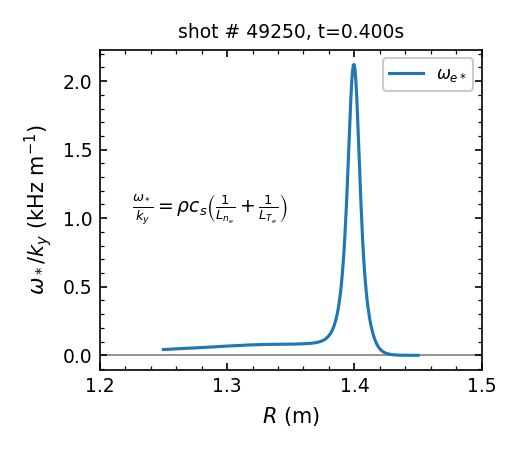

In [8]:
omega_star_e = gyro_e * cs * ((1. / Lne) + (1. / LTe))
# omega_star_i = gyro_i * cs * ((1. / Lne) + (1. / LTe))

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R, omega_star_e/1e3, label='$\\omega_{e*}$')
# ax.plot(R, omega_star_i/1e3, label='$\\omega_{i*}$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.set_xlim(xlim)
ax.text(
    xlim[0]+0.025, np.mean(ax.get_ylim()), 
    '$\\frac{\\omega_*}{k_y} = \\rho c_s \\left(\\frac{1}{L_{n_e}} + \\frac{1}{L_{T_e}} \\right)$',
    ha='left', va='center', fontsize=9
)
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)
plt.tight_layout()

plt.savefig(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_07.png')

In [9]:
np.savetxt(f'/home/sthoma/Documents/MU04/EST-05/{shotn}_{twant:.4f}s_results.txt', np.vstack((R, omega_star_e)).T)

In [10]:
def forward(x):
    return np.interp(x, R, psiN)
def inverse(x):
    return np.interp(x, psiN, R)

In [11]:
psiN = eq.psiN(R, 0.01)[0]
psi = eq.psi(R, 0.01)[0]
qprofile = np.zeros_like(psi)
for i in range(0, len(psi)):
    try:
        qprofile[i] = -eq.qpsi(psi[i])
    except ValueError:
        pass
qboo = ~np.isclose(qprofile, 0.)
Rsep = np.interp(1., psiN, R)

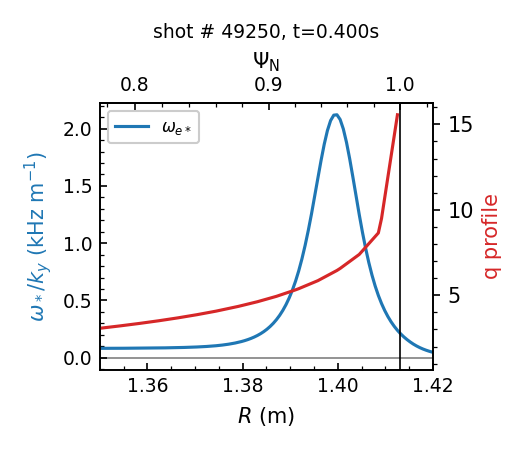

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

ax.plot(R, omega_star_e/1e3, label='$\\omega_{e*}$')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$\\omega_* / k_y$ (kHz m$^{-1}$)', c='C0')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=False
)
ax.minorticks_on()
ax.set_xlim((1.35,1.42))
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)


secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()


ax2 = ax.twinx()
ax2.plot(R[qboo], qprofile[qboo], c='C3')
ax2.set_ylabel('q profile', c='C3')
ax2.minorticks_on()


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.plot([Rsep,Rsep], ylim, '-k', lw=0.8)


plt.tight_layout()

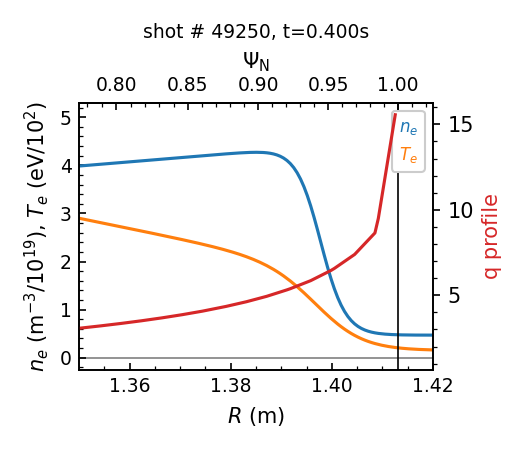

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)

ax.plot(R, profile2ne/1e19, label='$n_e$')
ax.plot(R, profile2Te/100., label='$T_e$')
ax.legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax.plot(xlim, [0.,0.], '-', c='gray', lw=0.8, zorder=0)
ax.set_xlabel('$R$ (m)')
ax.set_ylabel('$n_e$ (m$^{-3}$/10$^{19}$), $T_e$ (eV/10$^2$)')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=False, top=False
)
ax.minorticks_on()
ax.set_xlim((1.35,1.42))
ax.set_title(f'shot # {shotn}, t={twant:.3f}s', fontsize=9)


secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()


ax2 = ax.twinx()
ax2.plot(R[qboo], qprofile[qboo], c='C3')
ax2.set_ylabel('q profile', c='C3')
ax2.minorticks_on()


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.plot([Rsep,Rsep], ylim, '-k', lw=0.8)


plt.tight_layout()